# Part 2: Image Segmentation Assignment
## Using Mask R-CNN, YOLO, and SAM

## 1. Setup and Installation

In [2]:
%%capture

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install opencv-python matplotlib scikit-image numpy pillow
!pip install segment-anything ultralytics
!pip install git+https://github.com/facebookresearch/segment-anything.git

In [3]:
# Download SAM checkpoint (ViT-B model)
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-04-13 14:07:00--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.165.98.119, 18.165.98.56, 18.165.98.32, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.165.98.119|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   373MB/s    in 1.0s    

2026-04-13 14:07:01 (373 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



## 2. Import Libraries

In [4]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from torchvision.transforms import functional as F
from skimage.measure import label, regionprops
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


## 3. Helper Functions for Visualization and Counting

In [5]:
def count_objects_connected_components(binary_mask, min_area=10):
    """
    Count objects using connected component analysis
    
    Args:
        binary_mask: Binary mask (numpy array)
        min_area: Minimum area threshold to filter noise
    
    Returns:
        count: Number of objects
        objects: List of region properties
    """
    labeled = label(binary_mask)
    props = regionprops(labeled)
    objects = [p for p in props if p.area > min_area]
    return len(objects), objects


def visualize_instance_masks(image, masks, boxes=None, title="Instance Segmentation"):
    """
    Visualize instance segmentation with color-coded masks
    
    Args:
        image: Original image (RGB)
        masks: List of binary masks
        boxes: Optional list of bounding boxes
        title: Plot title
    """
    overlay = image.copy()
    np.random.seed(42)
    
    # Apply colored masks
    for i, mask in enumerate(masks):
        color = np.random.randint(50, 255, 3)
        overlay[mask] = overlay[mask] * 0.4 + color * 0.6
    
    plt.figure(figsize=(12, 8))
    plt.imshow(overlay.astype(np.uint8))
    
    # Draw bounding boxes if provided
    if boxes is not None:
        ax = plt.gca()
        for box in boxes:
            x1, y1, x2, y2 = box
            rect = Rectangle((x1, y1), x2-x1, y2-y1, 
                           linewidth=2, edgecolor='yellow', facecolor='none')
            ax.add_patch(rect)
    
    plt.title(f"{title} - {len(masks)} objects detected", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    return overlay.astype(np.uint8)


def draw_counting_visualization(image, objects, title="Object Counting"):
    """
    Draw bounding boxes and centroids with numbering
    
    Args:
        image: Original image (RGB)
        objects: List of region properties from regionprops
        title: Plot title
    """
    vis_image = image.copy()
    
    plt.figure(figsize=(12, 8))
    plt.imshow(vis_image)
    ax = plt.gca()
    
    # Draw each object with numbering
    for idx, obj in enumerate(objects, 1):
        # Get bounding box
        minr, minc, maxr, maxc = obj.bbox
        
        # Draw rectangle
        rect = Rectangle((minc, minr), maxc-minc, maxr-minr,
                        linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        
        # Draw centroid
        cy, cx = obj.centroid
        plt.plot(cx, cy, 'r+', markersize=15, markeredgewidth=2)
        
        # Add number label
        plt.text(minc, minr-5, str(idx), 
                color='yellow', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    plt.title(f"{title} - Total: {len(objects)} objects", 
             fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()

## 4. Model 1: Mask R-CNN (Instance Segmentation)

Mask R-CNN detects individual object instances and generates segmentation masks for each.

In [6]:
class MaskRCNNSegmenter:
    """
    Mask R-CNN for instance segmentation
    Pre-trained on COCO dataset
    """
    
    def __init__(self, score_threshold=0.001):
        print("Loading Mask R-CNN model...")
        self.model = torchvision.models.detection.maskrcnn_resnet50_fpn(
            weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
        )
        self.model.to(DEVICE)
        self.model.eval()
        self.score_threshold = score_threshold
        print("Mask R-CNN loaded successfully!")
    
    def segment(self, image_path):
        """
        Perform instance segmentation
        
        Returns:
            Dictionary with masks, boxes, scores, and count
        """
        # Load and prepare image
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Convert to tensor
        tensor = F.to_tensor(image_rgb).to(DEVICE)
        
        # Run inference
        with torch.no_grad():
            predictions = self.model([tensor])[0]
        
        # Extract valid predictions
        scores = predictions['scores'].cpu().numpy()
        masks = predictions['masks'].cpu().numpy()
        boxes = predictions['boxes'].cpu().numpy()
        
        # Filter by score threshold
        valid_idx = scores > self.score_threshold
        
        valid_masks = []
        valid_boxes = []
        
        for i in range(len(scores)):
            if valid_idx[i]:
                mask = masks[i, 0] > 50
                valid_masks.append(mask)
                valid_boxes.append(boxes[i])
        
        return {
            'masks': valid_masks,
            'boxes': valid_boxes,
            'count': len(valid_masks),
            'image': image_rgb,
            'method': 'Mask R-CNN'
        }
    
    def visualize_results(self, result):
        """
        Create comprehensive visualization
        """
        image = result['image']
        masks = result['masks']
        boxes = result['boxes']
        count = result['count']
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Original image
        axes[0].imshow(image)
        axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[0].axis('off')
        
        # Instance masks
        overlay = image.copy()
        np.random.seed(42)
        for mask in masks:
            color = np.random.randint(50, 255, 3)
            overlay[mask] = overlay[mask] * 0.4 + color * 0.6
        
        axes[1].imshow(overlay.astype(np.uint8))
        axes[1].set_title(f'Instance Masks\nCount: {count}', 
                         fontsize=12, fontweight='bold')
        axes[1].axis('off')
        
        # With bounding boxes
        axes[2].imshow(overlay.astype(np.uint8))
        for i, box in enumerate(boxes, 1):
            x1, y1, x2, y2 = box
            rect = Rectangle((x1, y1), x2-x1, y2-y1,
                           linewidth=2, edgecolor='yellow', facecolor='none')
            axes[2].add_patch(rect)
            axes[2].text(x1, y1-5, str(i), color='yellow', 
                        fontsize=10, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', 
                                facecolor='black', alpha=0.7))
        
        axes[2].set_title(f'Instances with Bounding Boxes\nTotal: {count}', 
                         fontsize=12, fontweight='bold')
        axes[2].axis('off')
        
        plt.tight_layout()
        return fig

## 5. Model 2: YOLO (Semantic Segmentation)


In [7]:
from ultralytics import YOLO

class YOLOSegmenter:
    """
    YOLOv8/11 segmentation for instance segmentation
    Pre-trained on COCO dataset
    """
    
    def __init__(self, model_name="yolo11n-seg.pt", conf_threshold=0.001):
        print("Loading YOLO segmentation model...")
        self.model = YOLO(model_name)
        self.conf_threshold = conf_threshold
        print("YOLO loaded successfully!")
    
    def segment(self, image_path, min_area=100):
        """
        Perform instance segmentation using YOLO Seg
        
        Returns:
            Dictionary with segmentation masks, boxes, and count
        """
        # Load image
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image_rgb.shape[:2]   # ⭐ original image size
        
        # Run inference
        results = self.model.predict(
            source=image_rgb,
            conf=self.conf_threshold,
            verbose=False
        )
        result = results[0]
        
        valid_masks = []
        objects = []
        overlay = image_rgb.copy()
        np.random.seed(42)
        
        # If masks exist, process each detected instance
        if result.masks is not None and result.boxes is not None:
            mask_data = result.masks.data.cpu().numpy()          # [N, 640, 640]
            boxes = result.boxes.xyxy.cpu().numpy()              # [N, 4]
            scores = result.boxes.conf.cpu().numpy()             # [N]
            classes = result.boxes.cls.cpu().numpy().astype(int) # [N]
            
            for i, mask in enumerate(mask_data):
                
                # 🚨 CRITICAL FIX — resize mask back to original image size
                mask_resized = cv2.resize(mask, (w, h))
                binary_mask = mask_resized > 0.50
                binary_uint8 = binary_mask.astype(np.uint8)
                
                # Contour-based area check
                contours, _ = cv2.findContours(
                    binary_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                )
                
                if not contours:
                    continue
                
                area = sum(cv2.contourArea(c) for c in contours)
                if area < min_area:
                    continue
                
                # Keep this instance
                valid_masks.append(binary_mask)
                
                # Bounding box (already in original image scale)
                x1, y1, x2, y2 = boxes[i].astype(int)
                
                cls_id = classes[i]
                cls_name = self.model.names.get(cls_id, str(cls_id))
                conf = float(scores[i])
                
                objects.append({
                    "mask": binary_mask,
                    "area": float(area),
                    "bbox": (x1, y1, x2, y2),
                    "class_id": cls_id,
                    "class_name": cls_name,
                    "confidence": conf
                })
                
                # Overlay mask
                color = np.random.randint(50, 255, 3)
                overlay[binary_mask] = (
                    0.45 * overlay[binary_mask] + 0.55 * color
                ).astype(np.uint8)
        
        count = len(objects)
        
        return {
            "image": image_rgb,
            "masks": valid_masks,
            "objects": objects,
            "count": count,
            "overlay": overlay,
            "method": "YOLO-Seg"
        }
    
    def visualize_results(self, result):
        """
        Create comprehensive visualization
        """
        image = result["image"]
        overlay = result["overlay"]
        objects = result["objects"]
        count = result["count"]
        masks = result["masks"]
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        
        axes[0, 0].imshow(image)
        axes[0, 0].set_title("Original Image", fontsize=12, fontweight="bold")
        axes[0, 0].axis("off")
        
        axes[0, 1].imshow(overlay)
        axes[0, 1].set_title(
            f"YOLO Segmentation Overlay\nCount: {count}",
            fontsize=12, fontweight="bold"
        )
        axes[0, 1].axis("off")
        
        mask_viz = np.zeros_like(image)
        np.random.seed(42)
        for m in masks:
            color = np.random.randint(50, 255, 3)
            mask_viz[m] = color
        
        axes[1, 0].imshow(mask_viz)
        axes[1, 0].set_title("Instance Masks", fontsize=12, fontweight="bold")
        axes[1, 0].axis("off")
        
        axes[1, 1].imshow(image)
        for i, obj in enumerate(objects, 1):
            x1, y1, x2, y2 = obj["bbox"]
            rect = Rectangle((x1, y1), x2-x1, y2-y1,
                             linewidth=2, edgecolor="cyan", facecolor="none")
            axes[1, 1].add_patch(rect)
            
            axes[1, 1].text(
                x1, max(0, y1-5), f'{i}: {obj["class_name"]}',
                color="yellow", fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
            )
        
        axes[1, 1].set_title(f"YOLO Bounding Boxes\nTotal: {count}",
                             fontsize=12, fontweight="bold")
        axes[1, 1].axis("off")
        
        plt.tight_layout()
        return fig

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 6. Model 3: SAM (Segment Anything Model)

SAM is a foundation model that can segment any object without specific training.

In [8]:
class SAMSegmenter:
    """
    Segment Anything Model (SAM)
    Foundation model for universal segmentation
    """
    
    def __init__(self, checkpoint="sam_vit_b_01ec64.pth", model_type="vit_b"):
        print("Loading SAM model...")
        sam = sam_model_registry[model_type](checkpoint=checkpoint)
        sam.to(DEVICE)
        
        # Configure automatic mask generator
        self.mask_generator = SamAutomaticMaskGenerator(
            sam,
            points_per_side=12,
            pred_iou_thresh=0.97,
            stability_score_thresh=0.87,
            crop_n_layers=1,
            min_mask_region_area=500  # Filter small masks
        )
        print("SAM loaded successfully!")
    
    def segment(self, image_path, min_area=500):
        """
        Perform automatic mask generation
        
        Returns:
            Dictionary with masks and count
        """
        # Load image
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Generate masks
        masks = self.mask_generator.generate(image_rgb)
        
        # Filter by area and extract segmentation masks
        valid_masks = []
        valid_mask_data = []
        
        for m in masks:
            if m['area'] > min_area:
                valid_masks.append(m['segmentation'])
                valid_mask_data.append(m)
        
        # Sort by area (largest first)
        sorted_indices = sorted(range(len(valid_mask_data)), 
                              key=lambda i: valid_mask_data[i]['area'], 
                              reverse=True)
        
        valid_masks = [valid_masks[i] for i in sorted_indices]
        valid_mask_data = [valid_mask_data[i] for i in sorted_indices]
        
        return {
            'masks': valid_masks,
            'mask_data': valid_mask_data,
            'count': len(valid_masks),
            'image': image_rgb,
            'method': 'SAM'
        }
    
    def visualize_results(self, result):
        """
        Create comprehensive visualization
        """
        image = result['image']
        masks = result['masks']
        mask_data = result['mask_data']
        count = result['count']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        
        # Original image
        axes[0, 0].imshow(image)
        axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[0, 0].axis('off')
        
        # All masks with different colors
        overlay = image.copy()
        np.random.seed(42)
        for mask in masks:
            color = np.random.randint(50, 255, 3)
            overlay[mask] = overlay[mask] * 0.4 + color * 0.6
        
        axes[0, 1].imshow(overlay.astype(np.uint8))
        axes[0, 1].set_title(f'Automatic Masks\nCount: {count}', 
                            fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
        
        # Masks with bounding boxes and IDs
        axes[1, 0].imshow(overlay.astype(np.uint8))
        for i, m in enumerate(mask_data, 1):
            bbox = m['bbox']  # [x, y, w, h]
            x, y, w, h = bbox
            rect = Rectangle((x, y), w, h,
                           linewidth=2, edgecolor='yellow', facecolor='none')
            axes[1, 0].add_patch(rect)
            axes[1, 0].text(x, y-5, str(i), color='yellow',
                          fontsize=10, fontweight='bold',
                          bbox=dict(boxstyle='round,pad=0.3', 
                                  facecolor='black', alpha=0.7))
        
        axes[1, 0].set_title(f'Masks with Bounding Boxes\nTotal: {count}', 
                            fontsize=12, fontweight='bold')
        axes[1, 0].axis('off')
        
        # Mask size distribution
        areas = [m['area'] for m in mask_data]
        axes[1, 1].bar(range(1, len(areas)+1), areas, color='skyblue', edgecolor='navy')
        axes[1, 1].set_xlabel('Mask ID', fontsize=11)
        axes[1, 1].set_ylabel('Area (pixels)', fontsize=11)
        axes[1, 1].set_title('Mask Size Distribution', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig

## 7. Complete Pipeline: Process Images with All Models

In [9]:
def process_image_all_models(image_path, output_dir="results"):
    """
    Process single image with all three models
    
    Args:
        image_path: Path to input image
        output_dir: Directory to save results
    """
    os.makedirs(output_dir, exist_ok=True)
    
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    print(f"\n{'='*80}")
    print(f"Processing: {image_name}")
    print(f"{'='*80}\n")
    
    # Initialize models
    print("[1/3] Initializing Mask R-CNN...")
    maskrcnn = MaskRCNNSegmenter(score_threshold=0.009)
    
    print("\n[2/3] Initializing YOLO Segmentation...")
    yolo = YOLOSegmenter(model_name="yolov8n-seg.pt", conf_threshold=0.009)
    
    print("\n[3/3] Initializing SAM...")
    sam = SAMSegmenter()
    
    print("\n" + "-"*80)
    print("Running Segmentation Models")
    print("-"*80 + "\n")
    
    # Run segmentation
    print("Running Mask R-CNN...")
    maskrcnn_result = maskrcnn.segment(image_path)
    print(f"✓ Mask R-CNN detected {maskrcnn_result['count']} objects")
    
    print("\nRunning YOLO Segmentation...")
    yolo_result = yolo.segment(image_path)
    print(f"✓ YOLO detected {yolo_result['count']} objects")
    
    print("\nRunning SAM...")
    sam_result = sam.segment(image_path)
    print(f"✓ SAM detected {sam_result['count']} objects")
    
    # Create visualizations
    print("\n" + "-"*80)
    print("Generating Visualizations")
    print("-"*80 + "\n")
    
    print("Creating Mask R-CNN visualization...")
    fig1 = maskrcnn.visualize_results(maskrcnn_result)
    fig1.savefig(f"{output_dir}/{image_name}_maskrcnn.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Creating YOLO visualization...")
    fig2 = yolo.visualize_results(yolo_result)
    fig2.savefig(f"{output_dir}/{image_name}_yolo.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Creating SAM visualization...")
    fig3 = sam.visualize_results(sam_result)
    fig3.savefig(f"{output_dir}/{image_name}_sam.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Create comparison summary
    create_comparison_summary(image_path, maskrcnn_result, yolo_result, sam_result, output_dir)
    
    # Print summary
    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    print(f"Image: {image_name}")
    print(f"Mask R-CNN:  {maskrcnn_result['count']} objects")
    print(f"YOLO:        {yolo_result['count']} objects")
    print(f"SAM:         {sam_result['count']} objects")
    
    counts = [maskrcnn_result['count'], yolo_result['count'], sam_result['count']]
    print(f"\nAverage:     {np.mean(counts):.1f} objects")
    print(f"Std Dev:     {np.std(counts):.2f}")
    print("="*80 + "\n")
    
    return {
        'maskrcnn': maskrcnn_result,
        'yolo': yolo_result,
        'sam': sam_result
    }

## 8. Run Segmentation on Your Images

Update the image paths below with your actual image locations.

In [10]:
def create_comparison_summary(image_path, maskrcnn_result, yolo_result, sam_result, output_dir):
    """
    Create side-by-side comparison of all three models
    """
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Original image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    axes[0].imshow(image_rgb)
    axes[0].set_title("Original Image", fontsize=14, fontweight="bold")
    axes[0].axis("off")
    
    # ---------------- Mask R-CNN overlay ----------------
    overlay1 = image_rgb.copy()
    np.random.seed(42)
    for mask in maskrcnn_result['masks']:
        color = np.random.randint(50, 255, 3)
        overlay1[mask] = overlay1[mask] * 0.4 + color * 0.6
    axes[1].imshow(overlay1.astype(np.uint8))
    axes[1].set_title(f"Mask R-CNN\nCount: {maskrcnn_result['count']}", fontsize=14, fontweight="bold")
    axes[1].axis("off")
    
    # ---------------- YOLO overlay ----------------
    overlay2 = image_rgb.copy()
    np.random.seed(42)
    for mask in yolo_result['masks']:
        color = np.random.randint(50, 255, 3)
        overlay2[mask] = overlay2[mask] * 0.4 + color * 0.6
    axes[2].imshow(overlay2.astype(np.uint8))
    axes[2].set_title(f"YOLO\nCount: {yolo_result['count']}", fontsize=14, fontweight="bold")
    axes[2].axis("off")
    
    # ---------------- SAM overlay ----------------
    overlay3 = image_rgb.copy()
    np.random.seed(42)
    for mask in sam_result['masks']:
        color = np.random.randint(50, 255, 3)
        overlay3[mask] = overlay3[mask] * 0.4 + color * 0.6
    axes[3].imshow(overlay3.astype(np.uint8))
    axes[3].set_title(f"SAM\nCount: {sam_result['count']}", fontsize=14, fontweight="bold")
    axes[3].axis("off")
    
    plt.tight_layout()
    fig.savefig(f"{output_dir}/{image_name}_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Comparison saved: {output_dir}/{image_name}_comparison.png")


Processing: 1b

[1/3] Initializing Mask R-CNN...
Loading Mask R-CNN model...
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 211MB/s] 


Mask R-CNN loaded successfully!

[2/3] Initializing YOLO Segmentation...
Loading YOLO segmentation model...
YOLO loaded successfully!

[3/3] Initializing SAM...
Loading SAM model...
SAM loaded successfully!

--------------------------------------------------------------------------------
Running Segmentation Models
--------------------------------------------------------------------------------

Running Mask R-CNN...
✓ Mask R-CNN detected 18 objects

Running YOLO Segmentation...
✓ YOLO detected 16 objects

Running SAM...
✓ SAM detected 11 objects

--------------------------------------------------------------------------------
Generating Visualizations
--------------------------------------------------------------------------------

Creating Mask R-CNN visualization...


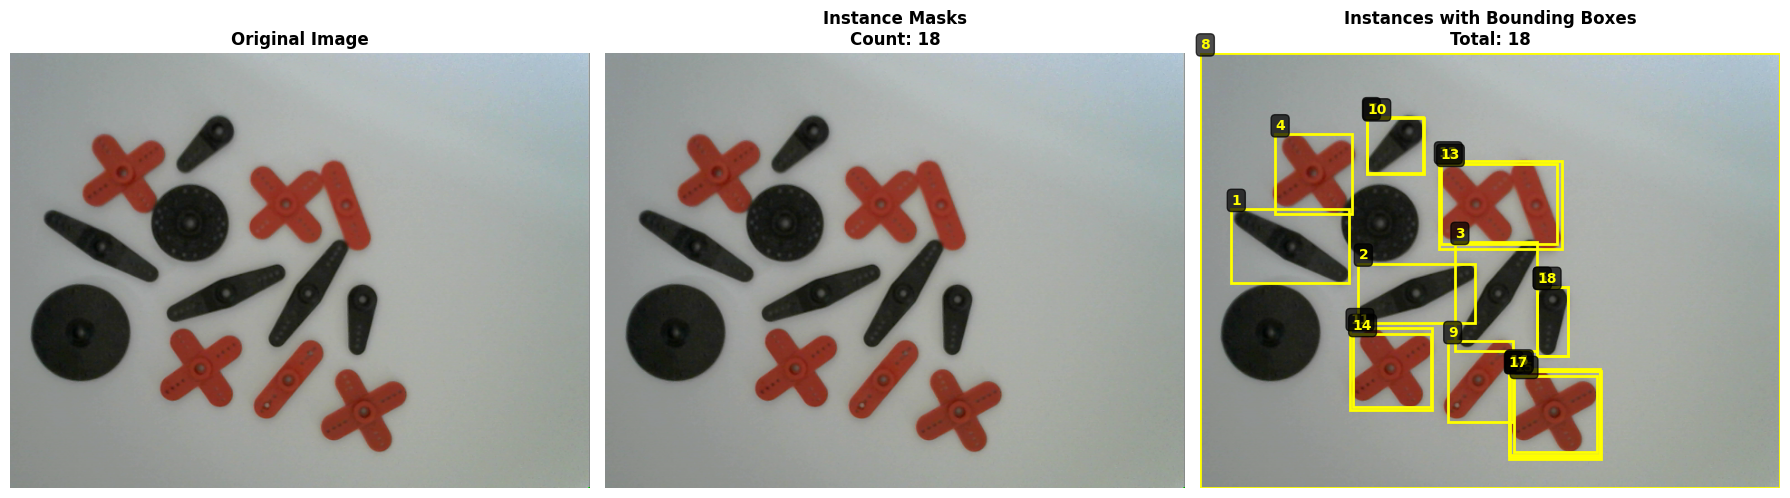

Creating YOLO visualization...


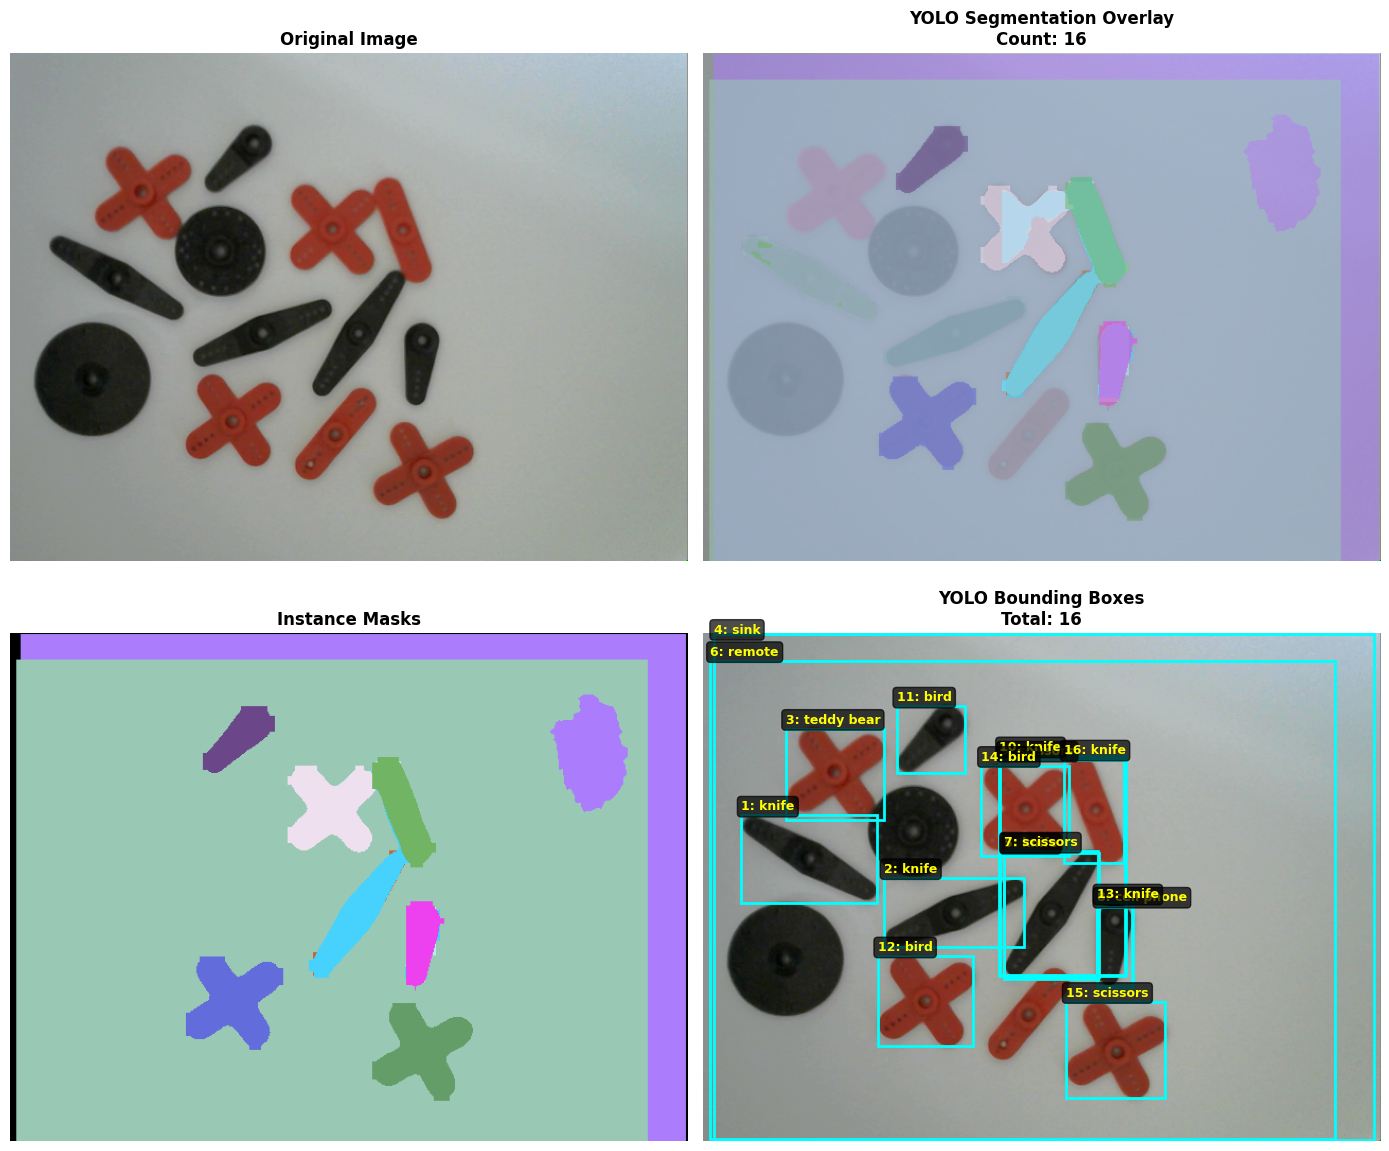

Creating SAM visualization...


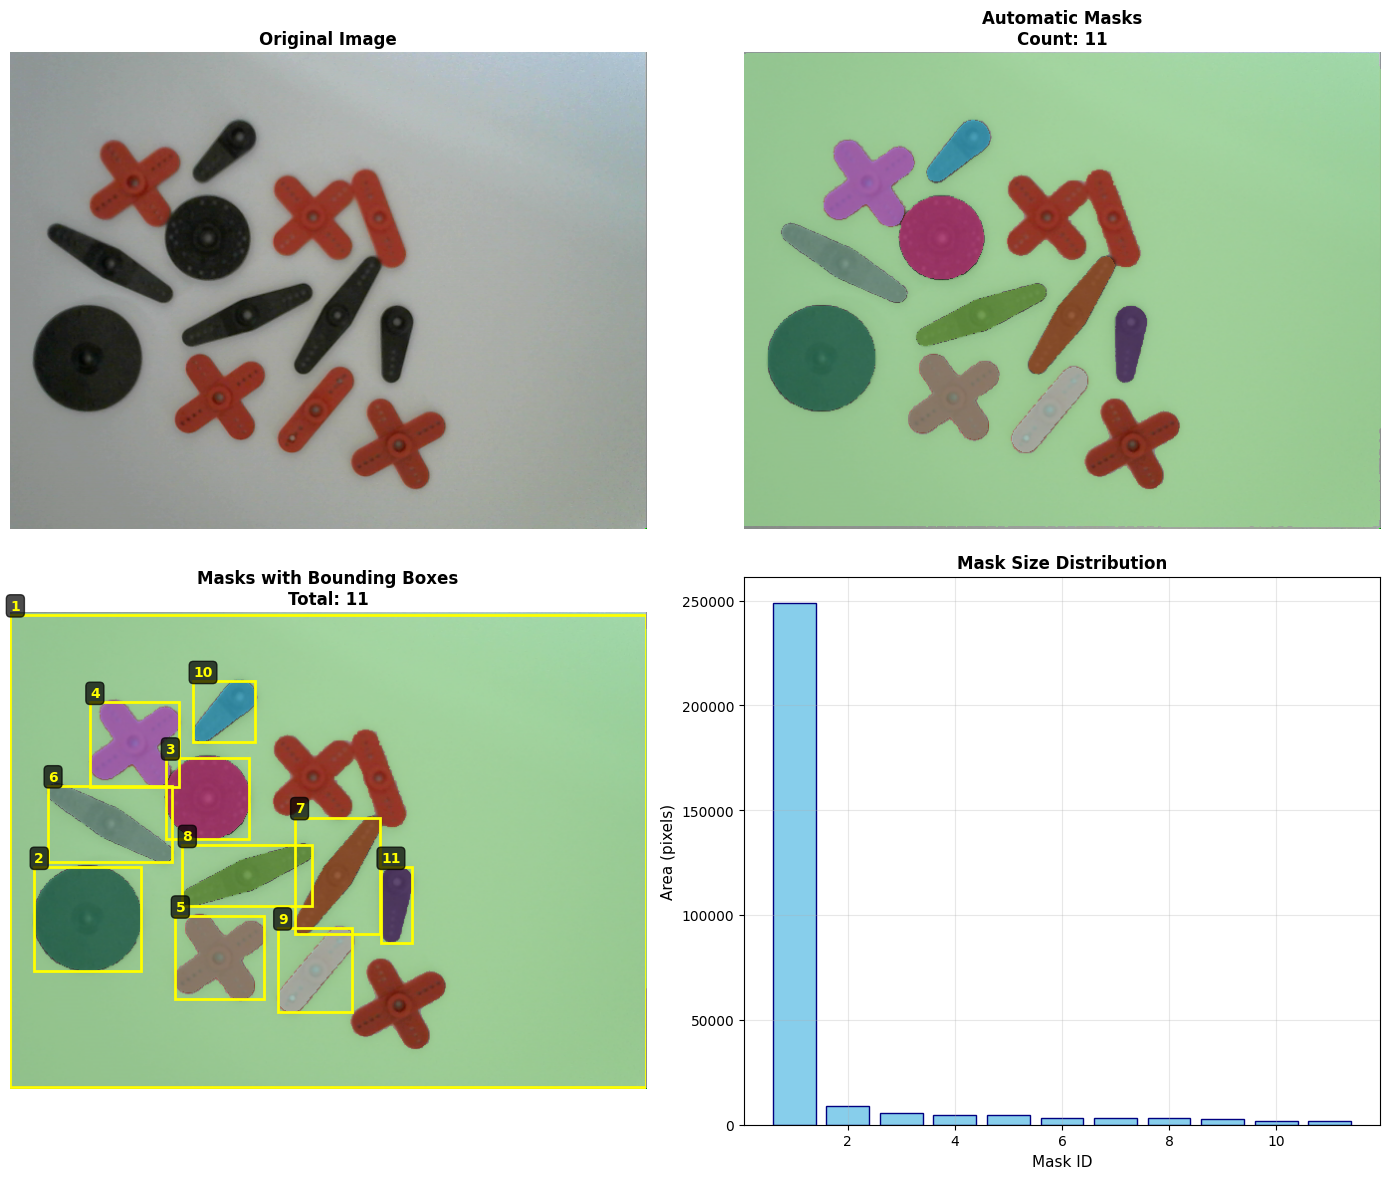

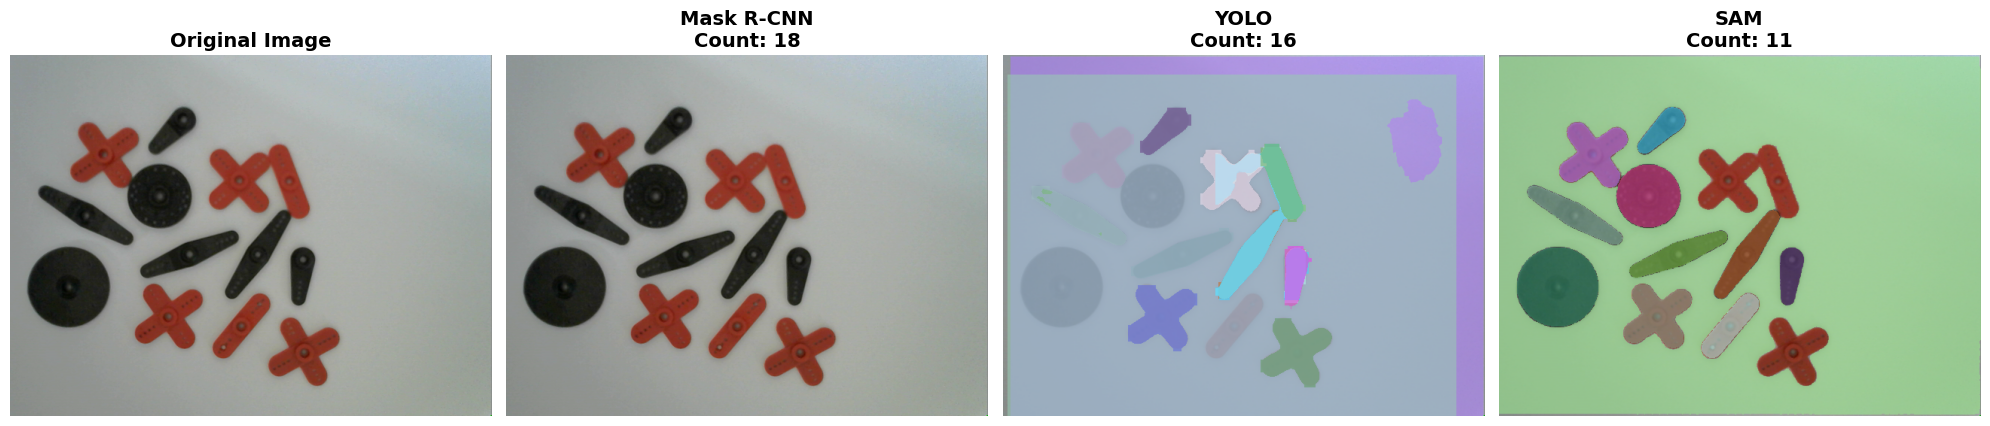

Comparison saved: segmentation_results/1b_comparison.png

SUMMARY
Image: 1b
Mask R-CNN:  18 objects
YOLO:        16 objects
SAM:         11 objects

Average:     15.0 objects
Std Dev:     2.94


Processing: experiment

[1/3] Initializing Mask R-CNN...
Loading Mask R-CNN model...
Mask R-CNN loaded successfully!

[2/3] Initializing YOLO Segmentation...
Loading YOLO segmentation model...
YOLO loaded successfully!

[3/3] Initializing SAM...
Loading SAM model...
SAM loaded successfully!

--------------------------------------------------------------------------------
Running Segmentation Models
--------------------------------------------------------------------------------

Running Mask R-CNN...
✓ Mask R-CNN detected 10 objects

Running YOLO Segmentation...
✓ YOLO detected 15 objects

Running SAM...
✓ SAM detected 3 objects

--------------------------------------------------------------------------------
Generating Visualizations
------------------------------------------------------------

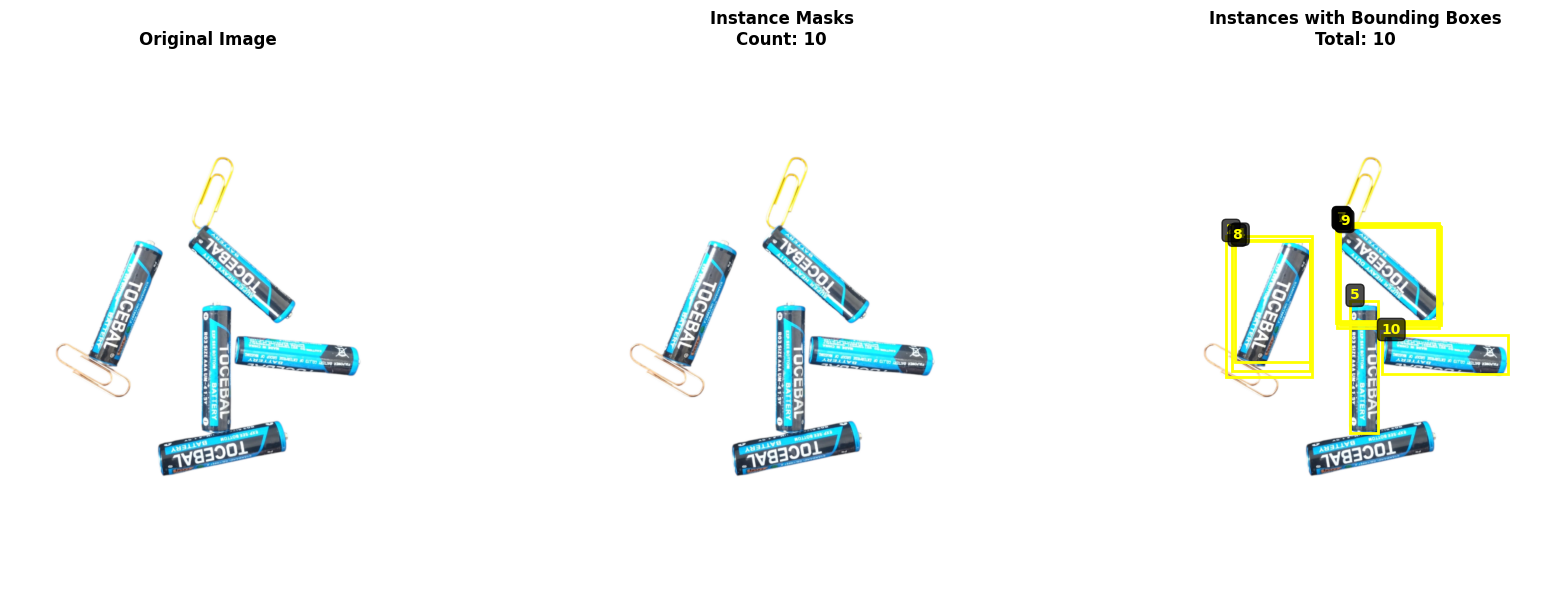

Creating YOLO visualization...


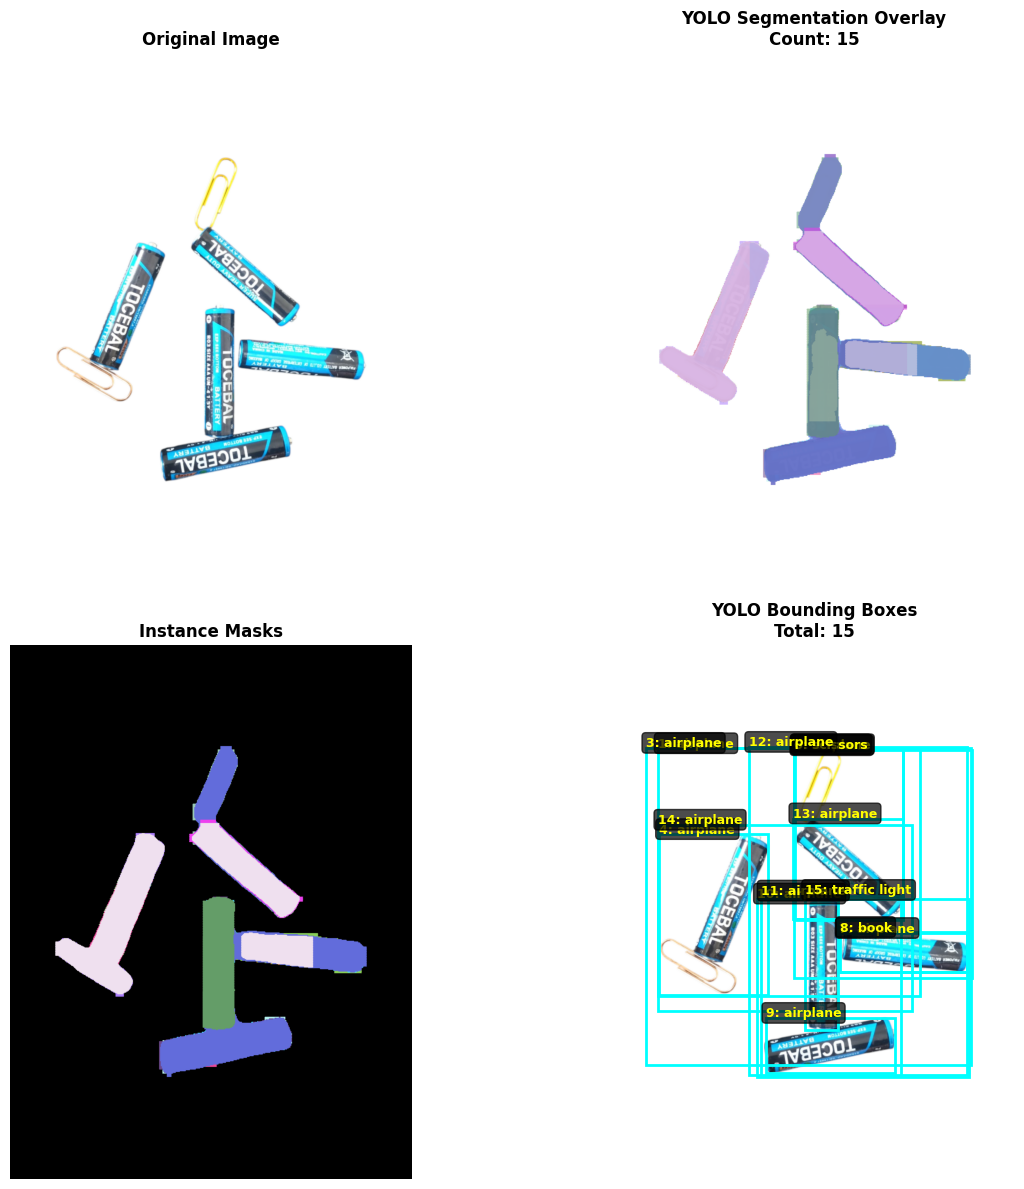

Creating SAM visualization...


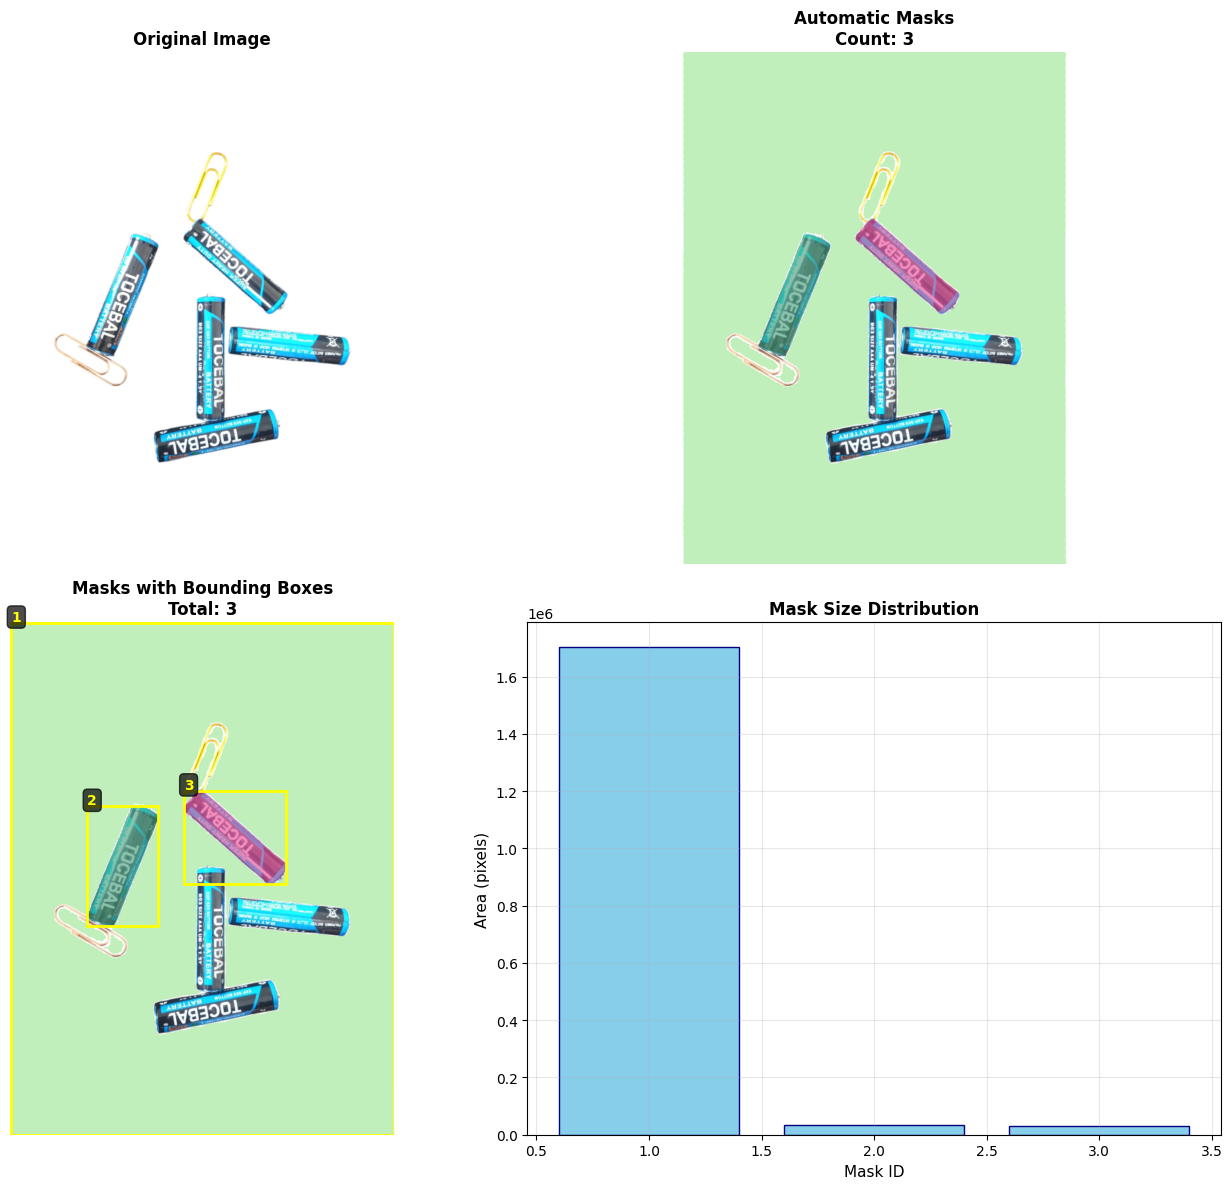

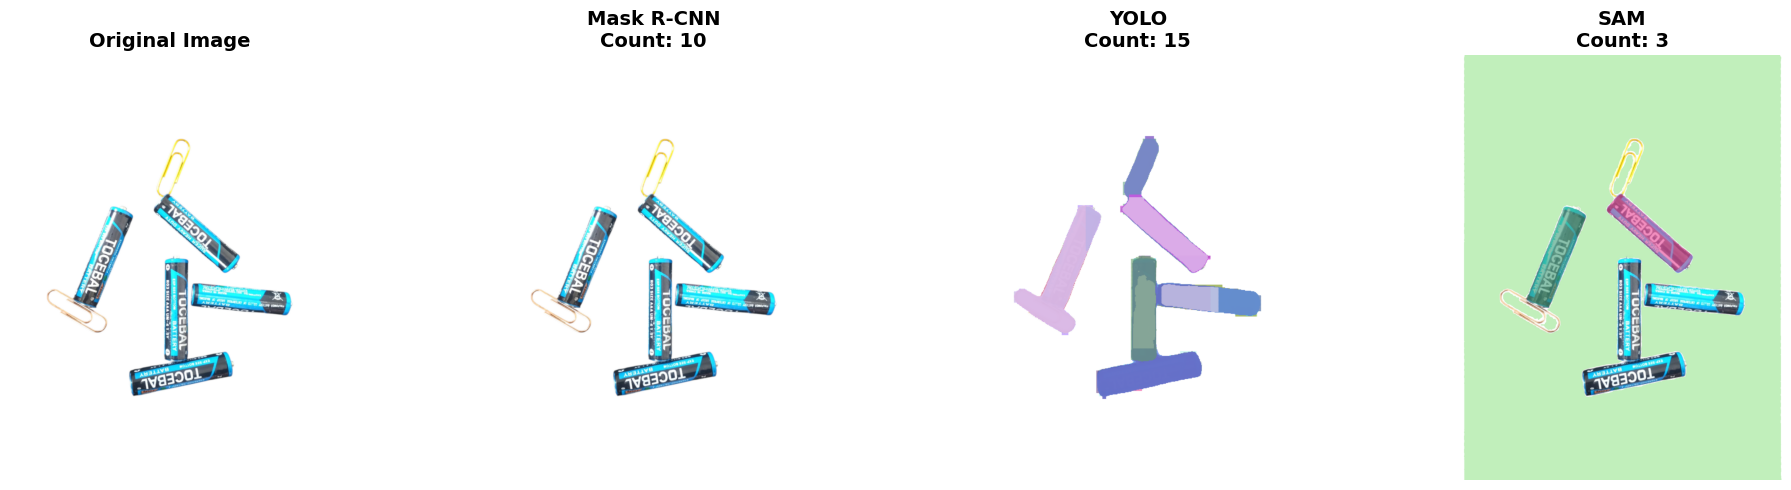

Comparison saved: segmentation_results/experiment_comparison.png

SUMMARY
Image: experiment
Mask R-CNN:  10 objects
YOLO:        15 objects
SAM:         3 objects

Average:     9.3 objects
Std Dev:     4.92


Processing: 1a

[1/3] Initializing Mask R-CNN...
Loading Mask R-CNN model...
Mask R-CNN loaded successfully!

[2/3] Initializing YOLO Segmentation...
Loading YOLO segmentation model...
YOLO loaded successfully!

[3/3] Initializing SAM...
Loading SAM model...
SAM loaded successfully!

--------------------------------------------------------------------------------
Running Segmentation Models
--------------------------------------------------------------------------------

Running Mask R-CNN...
✓ Mask R-CNN detected 7 objects

Running YOLO Segmentation...
✓ YOLO detected 17 objects

Running SAM...
✓ SAM detected 7 objects

--------------------------------------------------------------------------------
Generating Visualizations
-------------------------------------------------------

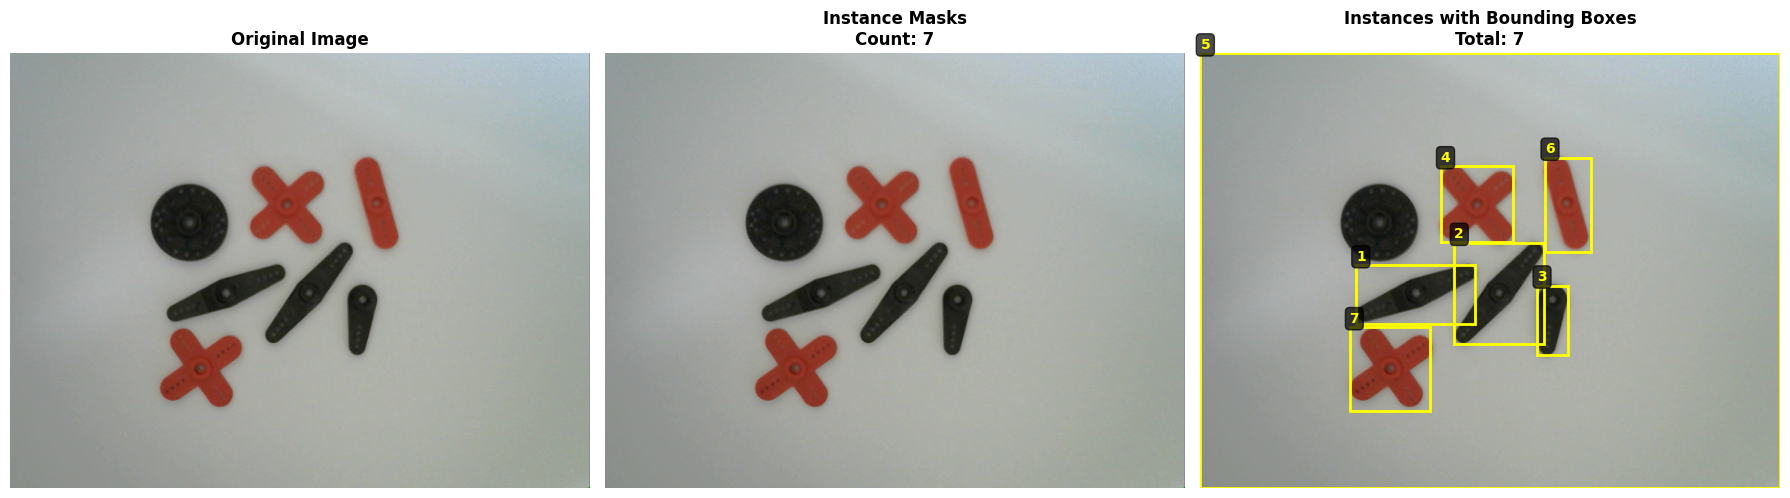

Creating YOLO visualization...


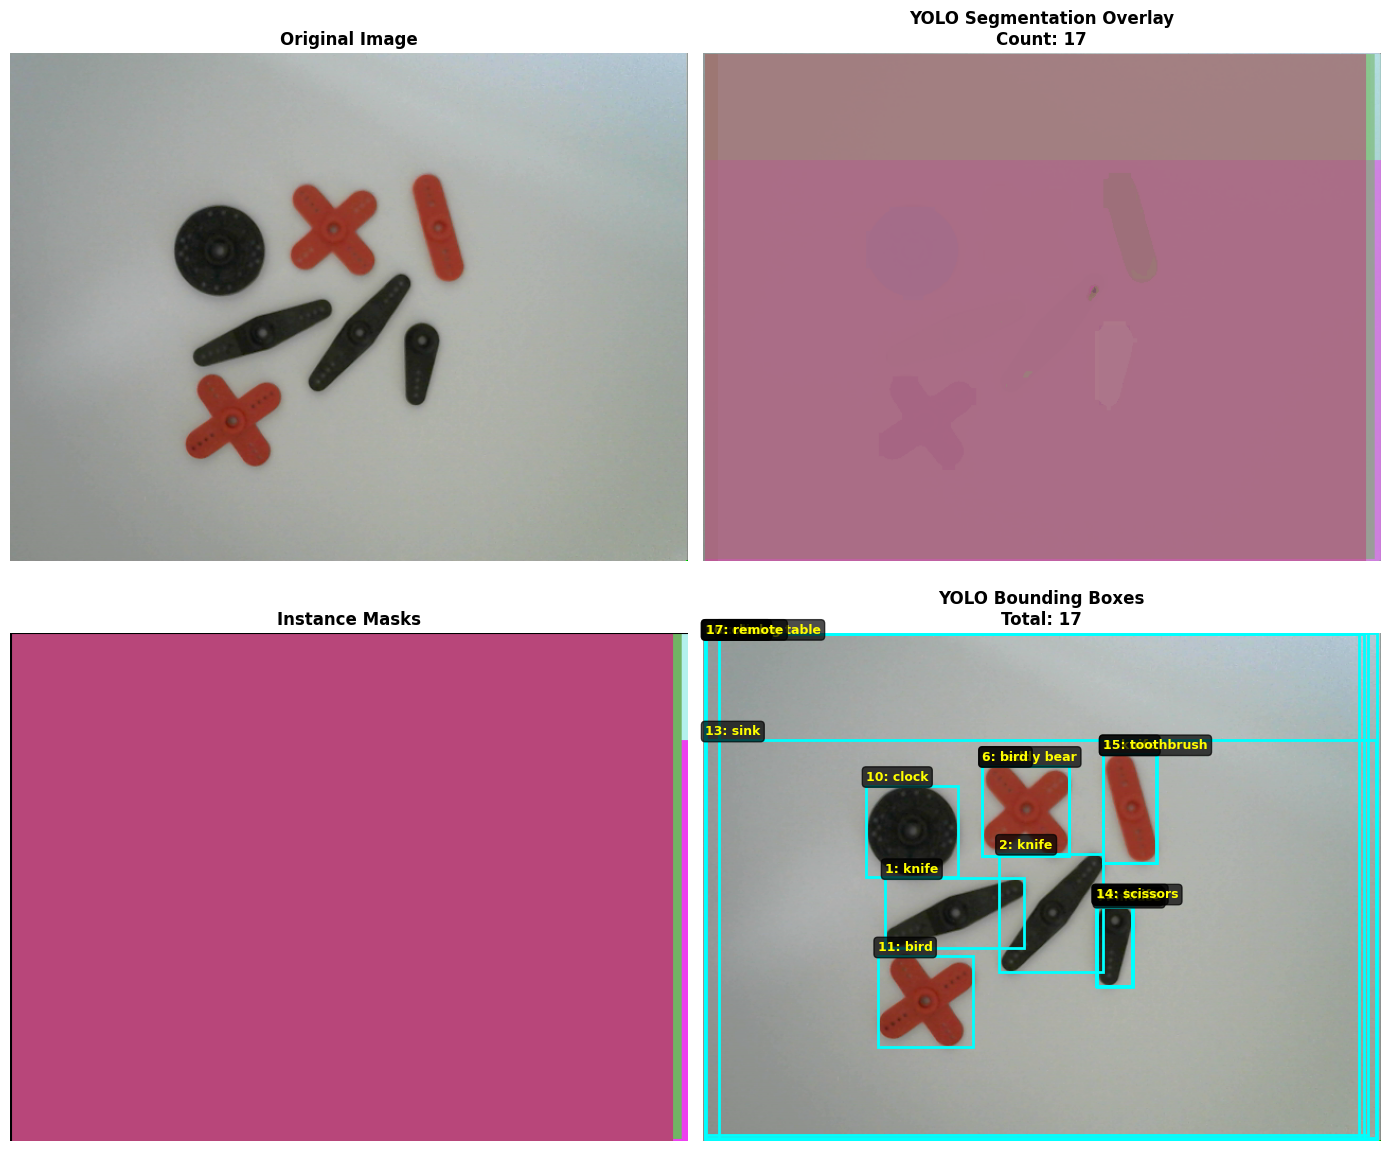

Creating SAM visualization...


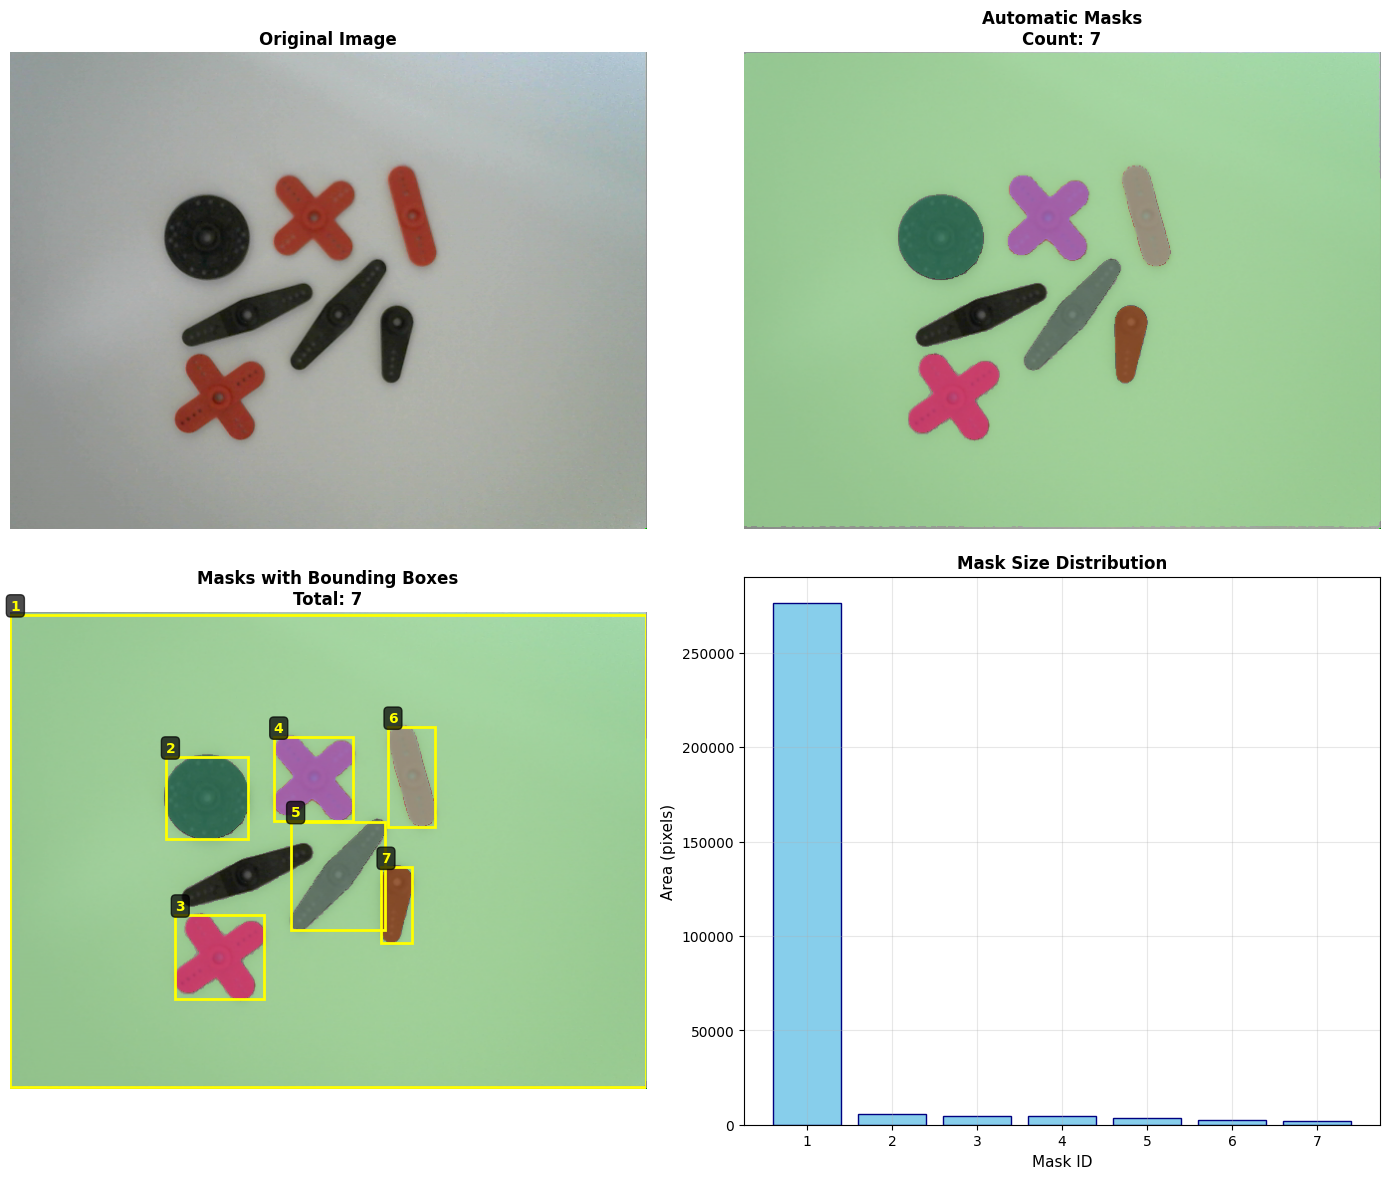

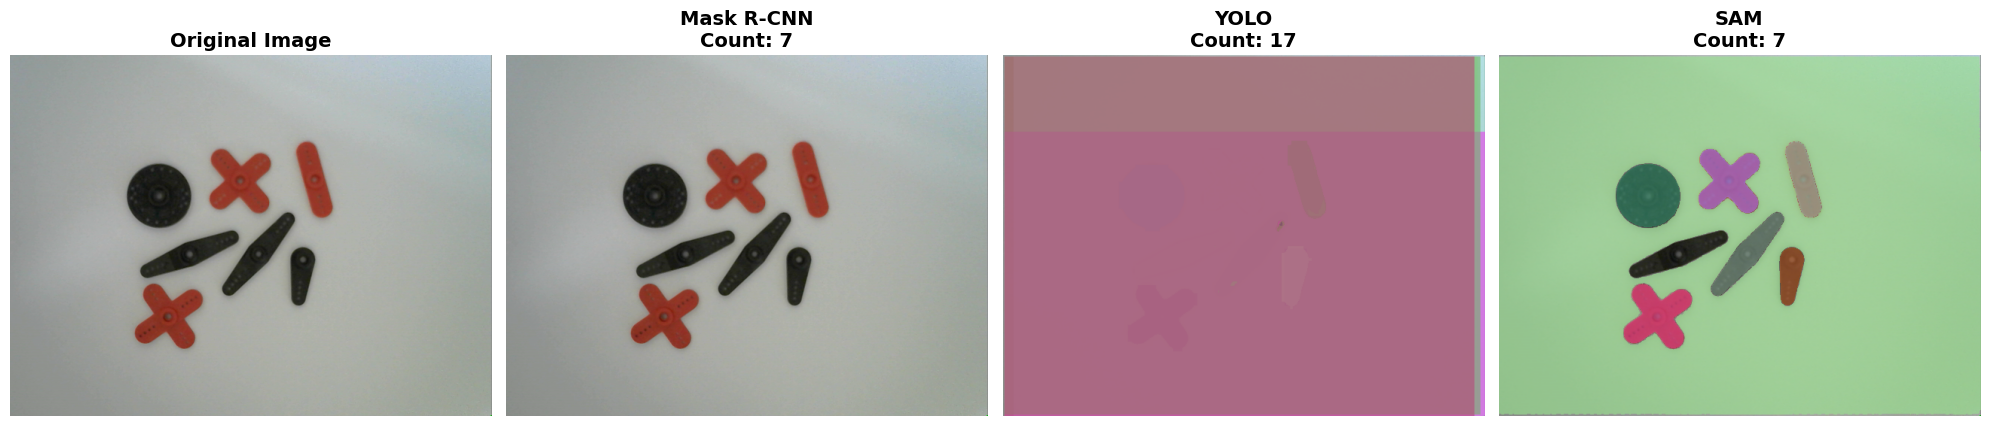

Comparison saved: segmentation_results/1a_comparison.png

SUMMARY
Image: 1a
Mask R-CNN:  7 objects
YOLO:        17 objects
SAM:         7 objects

Average:     10.3 objects
Std Dev:     4.71



In [11]:

image_folder = "/kaggle/input/datasets/martinkoome/segment"
image_paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder) 
               if f.endswith(('.png', '.jpg', '.jpeg'))]

# Process each image
all_results = []
for img_path in image_paths:
    if os.path.exists(img_path):
        results = process_image_all_models(img_path, output_dir="segmentation_results")
        all_results.append(results)
    else:
        print(f"Warning: Image not found: {img_path}")

## 9. Generate Final Report

In [12]:
def generate_final_report(image_paths, all_results, output_file="final_report.txt"):
    """
    Generate comprehensive text report for:
    Mask R-CNN vs YOLO Segmentation vs SAM
    """
    report = []
    report.append("="*80)
    report.append("PART 2: IMAGE SEGMENTATION - FINAL REPORT")
    report.append("="*80)

    report.append("\nModels Used:")
    report.append("1. Mask R-CNN  - Instance Segmentation")
    report.append("2. YOLOv8-Seg  - Instance Segmentation")
    report.append("3. SAM         - Segment Anything Model")
    report.append("\n" + "="*80)

    # ----------------------------------------------------
    # PER IMAGE RESULTS
    # ----------------------------------------------------
    for idx, (img_path, results) in enumerate(zip(image_paths, all_results), 1):
        image_name = os.path.basename(img_path)
        report.append(f"\nIMAGE {idx}: {image_name}")
        report.append("-"*80)

        maskrcnn_count = results['maskrcnn']['count']
        yolo_count     = results['yolo']['count']
        sam_count      = results['sam']['count']

        report.append(f"Mask R-CNN:  {maskrcnn_count} objects detected")
        report.append(f"YOLOv8-Seg:  {yolo_count} objects detected")
        report.append(f"SAM:         {sam_count} objects detected")

        counts = [maskrcnn_count, yolo_count, sam_count]

        report.append(f"\nStatistics:")
        report.append(f"  Average: {np.mean(counts):.2f}")
        report.append(f"  Std Dev: {np.std(counts):.2f}")
        report.append(f"  Min: {min(counts)}")
        report.append(f"  Max: {max(counts)}")

        # ⭐ best model per image (closest to median = robustness proxy)
        median_val = np.median(counts)
        best_model = ["MaskRCNN", "YOLO", "SAM"][np.argmin(np.abs(np.array(counts)-median_val))]
        report.append(f"  Most Consistent Model: {best_model}")

    # ----------------------------------------------------
    # OVERALL SUMMARY
    # ----------------------------------------------------
    report.append("\n" + "="*80)
    report.append("OVERALL SUMMARY")
    report.append("="*80)

    all_maskrcnn = [r['maskrcnn']['count'] for r in all_results]
    all_yolo     = [r['yolo']['count'] for r in all_results]
    all_sam      = [r['sam']['count'] for r in all_results]

    report.append(f"\nMask R-CNN Average: {np.mean(all_maskrcnn):.2f}")
    report.append(f"YOLOv8-Seg Average: {np.mean(all_yolo):.2f}")
    report.append(f"SAM Average:       {np.mean(all_sam):.2f}")

    report.append("\nDetection Stability (Std Dev):")
    report.append(f"Mask R-CNN Std: {np.std(all_maskrcnn):.2f}")
    report.append(f"YOLOv8-Seg Std: {np.std(all_yolo):.2f}")
    report.append(f"SAM Std:        {np.std(all_sam):.2f}")


    report.append("\n" + "="*80)

    # ----------------------------------------------------
    # SAVE REPORT
    # ----------------------------------------------------
    report_text = "\n".join(report)

    with open(output_file, 'w') as f:
        f.write(report_text)

    print(report_text)
    print(f"\nReport saved to: {output_file}")
    return report_text


# Generate report
if all_results:
    generate_final_report(image_paths, all_results, "segmentation_results/final_report.txt")

PART 2: IMAGE SEGMENTATION - FINAL REPORT

Models Used:
1. Mask R-CNN  - Instance Segmentation
2. YOLOv8-Seg  - Instance Segmentation
3. SAM         - Segment Anything Model


IMAGE 1: 1b.png
--------------------------------------------------------------------------------
Mask R-CNN:  18 objects detected
YOLOv8-Seg:  16 objects detected
SAM:         11 objects detected

Statistics:
  Average: 15.00
  Std Dev: 2.94
  Min: 11
  Max: 18
  Most Consistent Model: YOLO

IMAGE 2: experiment.png
--------------------------------------------------------------------------------
Mask R-CNN:  10 objects detected
YOLOv8-Seg:  15 objects detected
SAM:         3 objects detected

Statistics:
  Average: 9.33
  Std Dev: 4.92
  Min: 3
  Max: 15
  Most Consistent Model: MaskRCNN

IMAGE 3: 1a.png
--------------------------------------------------------------------------------
Mask R-CNN:  7 objects detected
YOLOv8-Seg:  17 objects detected
SAM:         7 objects detected

Statistics:
  Average: 10.33
  Std